## Exploratory Analysis
To begin this exploratory analysis, first import libraries and define functions for plotting the data using `matplotlib`. Depending on the data, not all plots will be made. (Hey, I'm just a simple kerneling bot, not a Kaggle Competitions Grandmaster!)

In [1]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


There are 2 csv files in the current version of the dataset:


In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/test.csv
/kaggle/input/train.csv


The next hidden code cells define functions for plotting data. Click on the "Code" button in the published kernel to reveal the hidden code.

In [3]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) / nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()


In [4]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    df = df.dropna('columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()


In [5]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna('columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()


Now you're ready to read in the data and use the plotting functions to visualize the data.

### Let's check 1st file: /kaggle/input/test.csv

In [6]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# test.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv('/kaggle/input/test.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'test.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 41 columns


Let's take a quick look at what the data looks like:

In [7]:
df1.head(5)

,ID,FoodGroup,Descrip,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,23116,Beef Products,"Beef, chuck, under blade steak, boneless, sepa...",275.0,28.23,18.00,0.00,0.00,0.0,8.0,...,0.0175,0.235750,0.173077,0.058333,0.011667,0.000100,0.047619,0.258571,0.585455,0.868182
1,10047,Pork Products,"Pork, fresh, loin, center rib (roasts), bone-i...",248.0,26.99,14.68,0.00,0.00,0.0,5.0,...,0.0000,0.593125,0.226923,0.435000,0.015833,0.000094,0.050000,0.328571,0.730909,0.264545
2,15270,Finfish and Shellfish Products,"Crustaceans, shrimp, untreated, raw",85.0,20.10,0.51,0.00,0.00,0.0,0.0,...,0.0000,0.000000,0.000000,0.000000,0.053333,0.000434,0.083333,0.305714,0.000000,0.121818
3,1259,Dairy and Egg Products,"Cheese spread, American or Cheddar cheese base...",176.0,13.41,8.88,10.71,7.06,0.0,185.0,...,0.0000,0.009562,0.340000,0.031667,0.464167,0.000036,0.064286,1.330000,0.281818,0.164545
4,19100,Sweets,"Candies, fudge, chocolate, prepared-from-recipe",411.0,2.39,10.41,76.44,73.12,1.7,44.0,...,0.0100,0.011000,0.065385,0.021667,0.040833,0.000366,0.085714,0.101429,0.045455,0.100909


Distribution graphs (histogram/bar graph) of sampled columns:

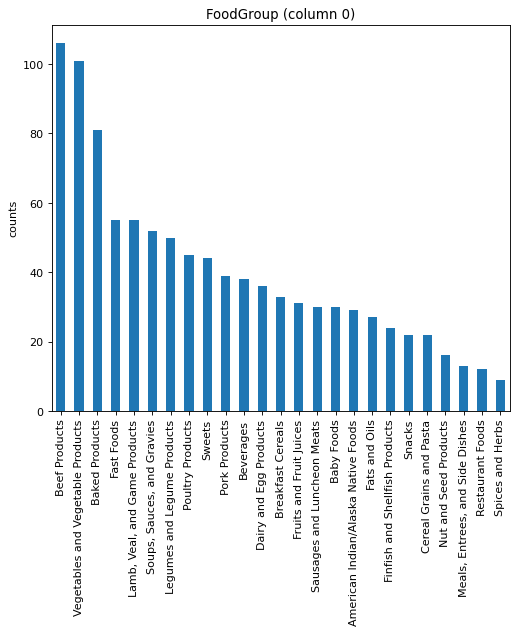

In [8]:
plotPerColumnDistribution(df1, 10, 5)

Correlation matrix:

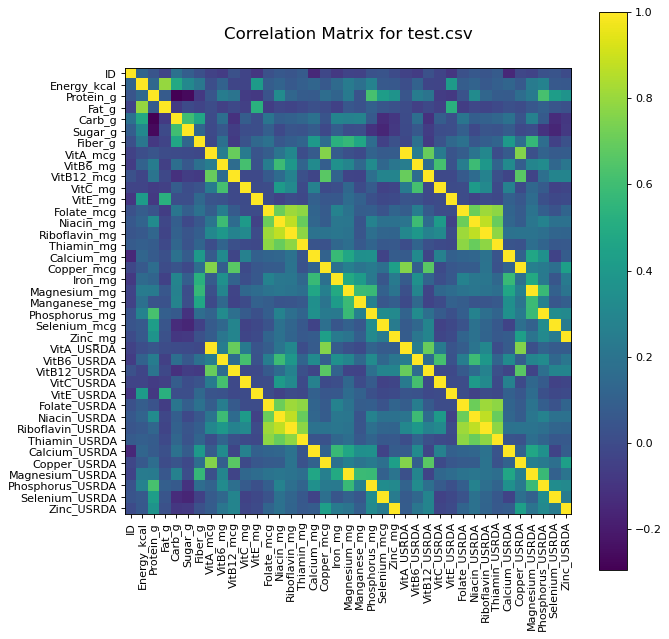

In [9]:
plotCorrelationMatrix(df1, 9)

Scatter and density plots:

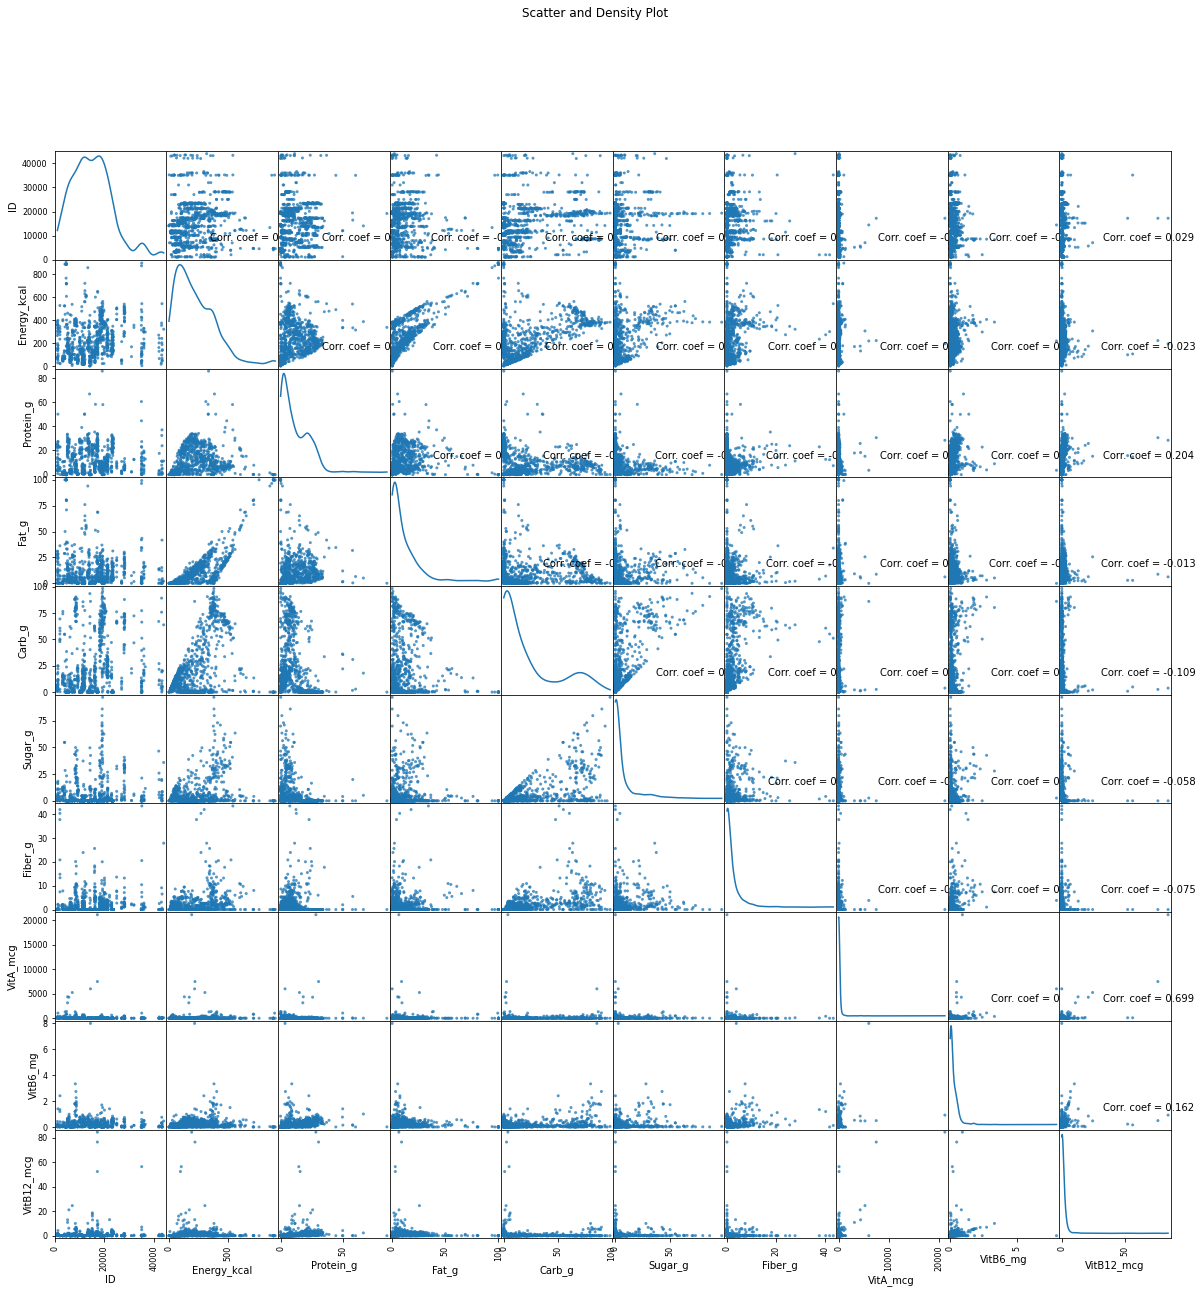

In [10]:
plotScatterMatrix(df1, 20, 10)

### Let's check 2nd file: /kaggle/input/train.csv

In [11]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# train.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df2 = pd.read_csv('/kaggle/input/train.csv', delimiter=',', nrows = nRowsRead)
df2.dataframeName = 'train.csv'
nRow, nCol = df2.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 41 columns


Let's take a quick look at what the data looks like:

In [12]:
df2.head(5)

,ID,FoodGroup,Descrip,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,16116,Legumes and Legume Products,"Soy flour, full-fat, roasted",441.0,34.80,21.86,33.67,7.61,9.7,6.0,...,0.5675,0.205375,0.723846,0.343333,0.156667,0.002468,0.878571,0.680000,0.136364,0.325455
1,18316,Baked Products,"Pie, coconut custard, commercially prepared",260.0,5.90,13.20,30.20,0.00,1.8,26.0,...,0.0475,0.025188,0.113846,0.073333,0.067500,0.000070,0.042857,0.174286,0.116364,0.061818
2,15261,Finfish and Shellfish Products,"Fish, tilapia, raw",96.0,20.08,1.70,0.00,0.00,0.0,0.0,...,0.0600,0.243938,0.048462,0.034167,0.008333,0.000083,0.064286,0.242857,0.760000,0.030000
3,8417,Breakfast Cereals,"Cereals, QUAKER, Instant Oatmeal, Banana Bread...",368.0,8.97,4.85,75.70,29.45,6.7,0.0,...,0.0000,0.706875,0.769231,0.816667,0.230833,0.000000,0.219048,0.450000,0.000000,0.188182
4,20022,Cereal Grains and Pasta,"Cornmeal, degermed, enriched, yellow",370.0,7.11,1.75,79.45,1.61,3.9,11.0,...,0.8375,0.310500,0.293846,0.459167,0.002500,0.000084,0.076190,0.141429,0.190909,0.060000


Distribution graphs (histogram/bar graph) of sampled columns:

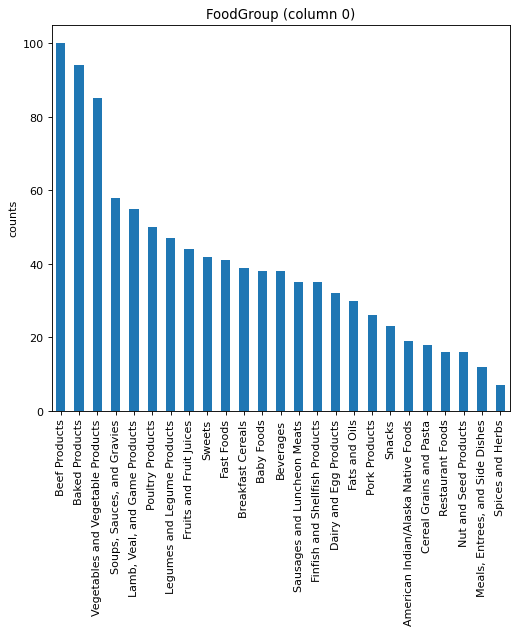

In [13]:
plotPerColumnDistribution(df2, 10, 5)

Correlation matrix:

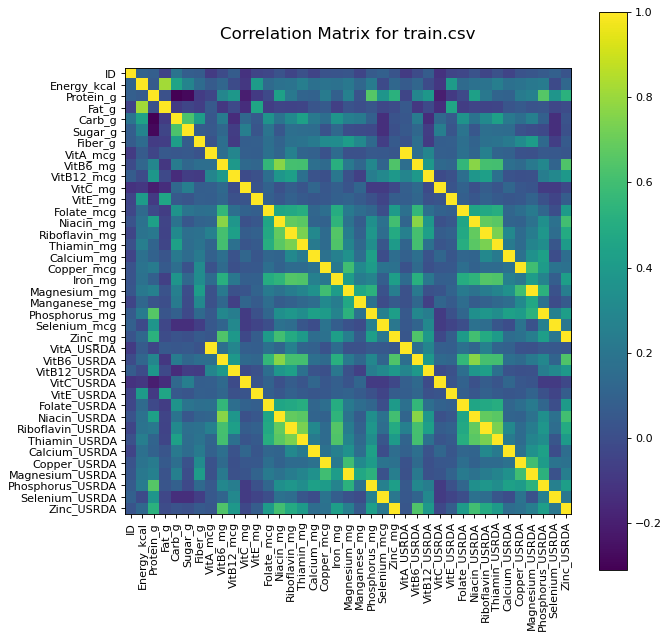

In [14]:
plotCorrelationMatrix(df2, 9)

Scatter and density plots:

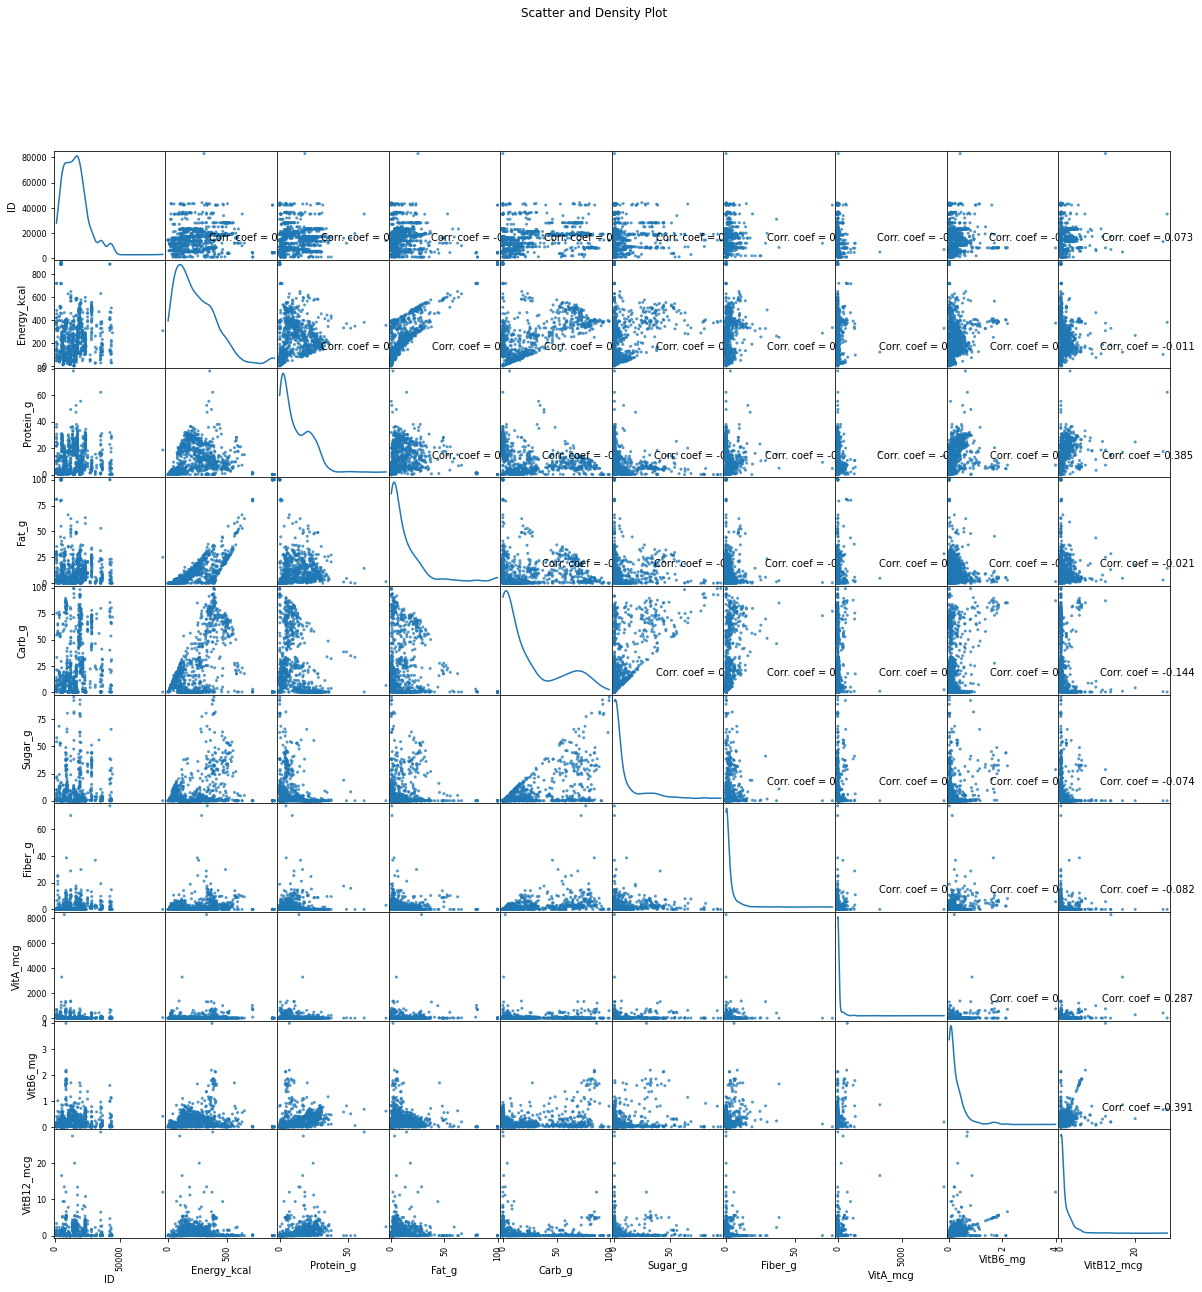

In [15]:
plotScatterMatrix(df2, 20, 10)